<a href="https://colab.research.google.com/github/miizuha/miizuha.github.io/blob/main/2627-1/notebooks/lecture-01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bài 1 · Làm quen công cụ: Colab, notebook & quy trình làm việc với AI

**Lập trình xử lý dữ liệu (LTXLDL) · 2627-1 · Viện TTNT, UET-VNU**

> 💡 **Việc đầu tiên:** File → **Save a copy in Drive** để lưu bản của riêng bạn — bản gốc này ai
> cũng xem được nhưng không sửa được.

**Mục tiêu buổi học** — sau notebook này, bạn sẽ:

1. Dùng thạo Colab: chạy cell, hiểu **trạng thái** của notebook, Restart & Run all.
2. Nạp một bảng dữ liệu thật từ URL và nhìn nó bằng pandas (chưa cần hiểu sâu — buổi 4 học kỹ).
3. Thực hành **quy trình kiểm chứng code AI** lần đầu tiên — kỹ năng xuyên suốt môn học.

## 1. Notebook hoạt động thế nào?

Notebook gồm các **cell**: cell chữ (Markdown, như cell này) và cell code (chạy bằng `Shift+Enter`).
Thử ngay:

In [1]:
print("Xin chào LTXLDL!")
3 * 7 + 1

Xin chào LTXLDL!


22

Hai điều vừa xảy ra: `print(...)` in ra màn hình, còn **giá trị của dòng cuối cùng** được notebook
tự hiển thị (không cần `print`). Đây là thói quen bạn sẽ dùng cả kỳ: gõ tên biến ở dòng cuối để xem nó.

In [2]:
loi_chao = "dữ liệu là dầu mỏ mới — nhưng phải lọc đã"
loi_chao.upper()

'DỮ LIỆU LÀ DẦU MỎ MỚI — NHƯNG PHẢI LỌC ĐÃ'

### Trạng thái (state) — thứ hay gây nhầm lẫn nhất

Biến sống **xuyên cell**: cell dưới dùng được `loi_chao` vừa tạo ở trên. Nhưng nếu bạn chạy cell
**không theo thứ tự**, trạng thái có thể không như bạn nghĩ.

Quy tắc: trước khi nộp/chia sẻ notebook, luôn **Restart session and run all** —
nếu chạy từ đầu mà lỗi thì notebook của bạn đang dựa vào trạng thái "ma".

In [3]:
# Cell này chạy được vì `loi_chao` đã tồn tại từ cell trước
print(len(loi_chao), "ký tự")

41 ký tự


## 2. Nhìn dữ liệu thật lần đầu

Nạp một bảng dữ liệu nổi tiếng: số đo 344 con chim cánh cụt ở Nam Cực. Chú ý: dữ liệu nằm trên
Internet, `pandas` đọc thẳng từ URL.

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
penguins = pd.read_csv(url)
penguins.head()          # 5 dòng đầu

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
penguins.shape           # (số dòng, số cột)

(344, 7)

In [6]:
# Một câu hỏi dữ liệu đầu tiên: mỗi loài có bao nhiêu con?
penguins["species"].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


Và một biểu đồ đầu tiên — mỗi chấm là một con chim, màu theo loài. **Chưa cần hiểu code** — đây là
"trailer" của buổi 12:

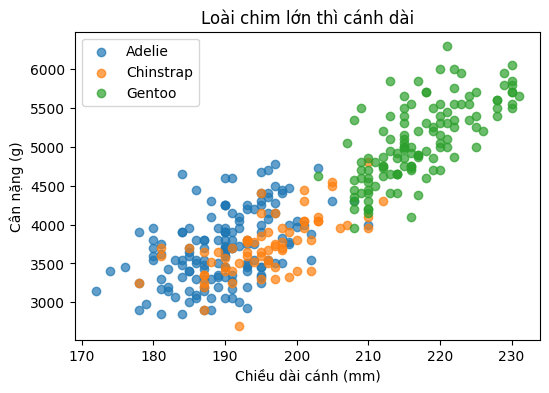

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
for species, g in penguins.groupby("species"):
    ax.scatter(g["flipper_length_mm"], g["body_mass_g"], label=species, alpha=0.7)
ax.set_xlabel("Chiều dài cánh (mm)")
ax.set_ylabel("Cân nặng (g)")
ax.set_title("Loài chim lớn thì cánh dài")
ax.legend()
plt.show()

## 3. Colab còn là một máy Linux

Dấu `!` chạy lệnh hệ điều hành — sau này dùng để cài thư viện, tải dữ liệu:

In [8]:
!python --version

Python 3.12.13


In [9]:
# Thư viện dữ liệu chính đã cài sẵn trên Colab:
import numpy, matplotlib
print("pandas", pd.__version__, "| numpy", numpy.__version__, "| matplotlib", matplotlib.__version__)

pandas 2.2.2 | numpy 2.0.2 | matplotlib 3.10.0


📌 **Ghi nhớ cho buổi 11:** cột trái Colab có mục **🔑 Secrets** — nơi cất API key an toàn
(không bao giờ dán key thẳng vào code). Hôm nay chưa cần, nhưng bạn sẽ gặp lại nó ở buổi 11.

## 4. Bài tập tại lớp

### Bài 1 — Bắt lỗi trạng thái

Code dưới **chạy không lỗi nhưng kết quả sai** (tổng của `[3, 5, 8]` phải là 16). Tìm chỗ sai, sửa,
chạy lại. Đây là kiểu lỗi AI *không bao giờ* báo cho bạn — vì không có thông báo lỗi nào cả.

In [10]:
# TODO: sửa 1 ký tự để ra 16
cac_so = [3, 5, 8]
tong = 0
for x in cac_so:
    tong += x
print("Tổng =", tong)

Tổng = 16


### Bài 2 — Kiểm chứng code AI (quy trình 5 bước trong slide)

1. **Tự phác:** bạn muốn đếm số chim theo loài; bạn đã biết đáp án đúng từ mục 2
   (`value_counts`: Adelie 152, Gentoo 124, Chinstrap 68).
2. **Hỏi AI:** mở ChatGPT/Gemini/Claude, prompt: *"Viết code pandas đếm số dòng theo cột species
   của DataFrame penguins"*.
3. **Dán code AI vào cell dưới** (thay code mẫu), **đọc hiểu từng dòng**.
4. **Kiểm chứng:** kết quả có khớp con số bạn đã biết không?
5. **Khai báo:** điền 2 dòng ở cell Markdown cuối.

In [11]:
# TODO: thay bằng code AI đưa cho bạn (code mẫu dưới là một cách AI hay trả lời)
species_counts = penguins['species'].value_counts()
print(species_counts)

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


### Bài 3 — Khai báo AI đầu tiên của bạn

Sửa cell này (double-click):

- **Công cụ đã dùng:** *(điền: ChatGPT/Gemini/... hoặc "không dùng")*: Gemini
- **AI đúng hay sai, kiểm chứng bằng cách nào:** *(1–2 câu)*: Đúng, kiểm tra các số tương ứng với loài khớp.

## 5. Bài tập về nhà

Dựng môi trường trên máy cá nhân (không bắt buộc, nên làm trước buổi 3):

1. Cài [Python 3.12+](https://www.python.org/downloads/) và [VS Code](https://code.visualstudio.com/)
   (kèm extension Python + Jupyter).
2. Mở terminal, tạo thư mục `ltxldl/`, tạo venv và cài thư viện:
   ```bash
   python -m venv .venv
   source .venv/bin/activate        # Windows: .venv\Scripts\activate
   pip install pandas matplotlib jupyter
   pip freeze > requirements.txt
   ```
3. Tải notebook này về (File → Download → .ipynb), mở bằng VS Code, chạy lại từ đầu đến cuối
   bằng chính venv vừa tạo.
4. Tự kiểm tra: `requirements.txt` của bạn có những gì? Vì sao nhiều hơn 3 thư viện bạn gõ?

Vướng ở bước nào — được phép hỏi AI thoải mái (✅ mở), nhưng nhớ nguyên tắc: **hiểu rồi mới chạy tiếp**.

---

## Tóm tắt buổi học

| Ý chốt | Vì sao quan trọng |
|---|---|
| Dòng cuối cell tự hiển thị; biến sống xuyên cell | Đọc/khám phá dữ liệu nhanh, nhưng phải cảnh giác trạng thái |
| **Restart & Run all** trước khi nộp | Notebook phải chạy được từ đầu — như pipeline bài tập lớn |
| pandas đọc dữ liệu thẳng từ URL | Buổi 4–6 sẽ sống trong `read_csv` và bạn bè của nó |
| Quy trình 5 bước với AI: phác → hỏi → hiểu → **kiểm chứng** → khai báo | Trách nhiệm ở chế độ ✅ mở — xem Chính sách AI |

**Trước buổi 2:** đọc trang Chính sách AI (có quiz 🚫 đóng), chạy hết notebook này.